<a href="https://www.kaggle.com/code/sonawanelalitsunil/podcast-listening-time-predictiondataset-ml-74-63?scriptVersionId=231204080" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/playground-series-s5e4/sample_submission.csv
/kaggle/input/playground-series-s5e4/train.csv
/kaggle/input/playground-series-s5e4/test.csv


## Title : Podcast Listening Time Prediction Dataset

#### About Us
We are dedicated to analyzing user engagement with podcasts to uncover insights into listening behavior. Our dataset is designed to help researchers, data scientists, and businesses predict podcast listening duration based on user preferences, demographics, content features, and historical engagement patterns.

With a focus on improving content recommendations, optimizing ad placements, and enhancing user experience, our dataset provides valuable information for developing machine learning models and data-driven strategies in the podcast industry.

## Import libraries

In [2]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

## Import dataset

In [3]:
train = pd.read_csv('/kaggle/input/playground-series-s5e4/train.csv')

In [4]:
test = pd.read_csv("/kaggle/input/playground-series-s5e4/test.csv")

In [5]:
train.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
0,0,Mystery Matters,Episode 98,NaN,True Crime,74.81,Thursday,Night,NaN,0.0,Positive,31.41998
1,1,Joke Junction,Episode 26,119.80,Comedy,66.95,Saturday,Afternoon,75.95,2.0,Negative,88.01241
2,2,Study Sessions,Episode 16,73.90,Education,69.97,Tuesday,Evening,8.97,0.0,Negative,44.92531
3,3,Digital Digest,Episode 45,67.17,Technology,57.22,Monday,Morning,78.70,2.0,Positive,46.27824
4,4,Mind & Body,Episode 86,110.51,Health,80.07,Monday,Afternoon,58.68,3.0,Neutral,75.61031


In [6]:
train.tail()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment,Listening_Time_minutes
749995,749995,Learning Lab,Episode 25,75.66,Education,69.36,Saturday,Morning,NaN,0.0,Negative,56.87058
749996,749996,Business Briefs,Episode 21,75.75,Business,35.21,Saturday,Night,NaN,2.0,Neutral,45.46242
749997,749997,Lifestyle Lounge,Episode 51,30.98,Lifestyle,78.58,Thursday,Morning,84.89,0.0,Negative,15.26000
749998,749998,Style Guide,Episode 47,108.98,Lifestyle,45.39,Thursday,Morning,93.27,0.0,Negative,100.72939
749999,749999,Sports Central,Episode 99,24.10,Sports,22.45,Saturday,Night,36.72,0.0,Neutral,11.94439


In [7]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 750000 entries, 0 to 749999
Data columns (total 12 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           750000 non-null  int64  
 1   Podcast_Name                 750000 non-null  object 
 2   Episode_Title                750000 non-null  object 
 3   Episode_Length_minutes       662907 non-null  float64
 4   Genre                        750000 non-null  object 
 5   Host_Popularity_percentage   750000 non-null  float64
 6   Publication_Day              750000 non-null  object 
 7   Publication_Time             750000 non-null  object 
 8   Guest_Popularity_percentage  603970 non-null  float64
 9   Number_of_Ads                749999 non-null  float64
 10  Episode_Sentiment            750000 non-null  object 
 11  Listening_Time_minutes       750000 non-null  float64
dtypes: float64(5), int64(1), object(6)
memory usage: 68.7+ MB


In [8]:
train. describe()

,id,Episode_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads,Listening_Time_minutes
count,750000.000000,662907.000000,750000.000000,603970.000000,749999.000000,750000.000000
mean,374999.500000,64.504738,59.859901,52.236449,1.348855,45.437406
std,216506.495284,32.969603,22.873098,28.451241,1.151130,27.138306
min,0.000000,0.000000,1.300000,0.000000,0.000000,0.000000
25%,187499.750000,35.730000,39.410000,28.380000,0.000000,23.178350
50%,374999.500000,63.840000,60.050000,53.580000,1.000000,43.379460
75%,562499.250000,94.070000,79.530000,76.600000,2.000000,64.811580
max,749999.000000,325.240000,119.460000,119.910000,103.910000,119.970000


In [9]:
train.isnull().sum()

id                                  0
Podcast_Name                        0
Episode_Title                       0
Episode_Length_minutes          87093
Genre                               0
Host_Popularity_percentage          0
Publication_Day                     0
Publication_Time                    0
Guest_Popularity_percentage    146030
Number_of_Ads                       1
Episode_Sentiment                   0
Listening_Time_minutes              0
dtype: int64

In [10]:
train.duplicated().sum()

0

In [11]:
train.shape

(750000, 12)

In [12]:
train.dtypes

id                               int64
Podcast_Name                    object
Episode_Title                   object
Episode_Length_minutes         float64
Genre                           object
Host_Popularity_percentage     float64
Publication_Day                 object
Publication_Time                object
Guest_Popularity_percentage    float64
Number_of_Ads                  float64
Episode_Sentiment               object
Listening_Time_minutes         float64
dtype: object

In [13]:
train.columns

Index(['id', 'Podcast_Name', 'Episode_Title', 'Episode_Length_minutes',
       'Genre', 'Host_Popularity_percentage', 'Publication_Day',
       'Publication_Time', 'Guest_Popularity_percentage', 'Number_of_Ads',
       'Episode_Sentiment', 'Listening_Time_minutes'],
      dtype='object')

## Data visualizations - Train dataset

In [14]:
# Set style
sns.set_style("darkgrid")
plt.rcParams.update({'axes.titlesize': 14, 'axes.labelsize': 12, 'xtick.labelsize': 10, 'ytick.labelsize': 10})

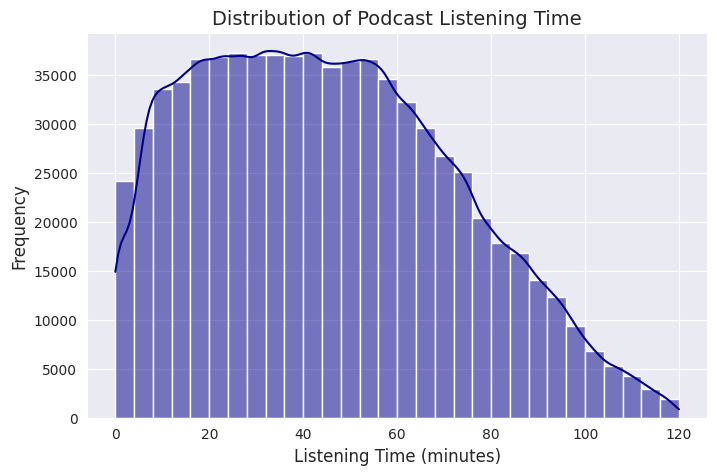

In [15]:
# 1. Distribution of Listening Time
plt.figure(figsize=(8, 5))
sns.histplot(train['Listening_Time_minutes'], bins=30, kde=True, color='darkblue')
plt.title("Distribution of Podcast Listening Time")
plt.xlabel("Listening Time (minutes)")
plt.ylabel("Frequency")
plt.show()

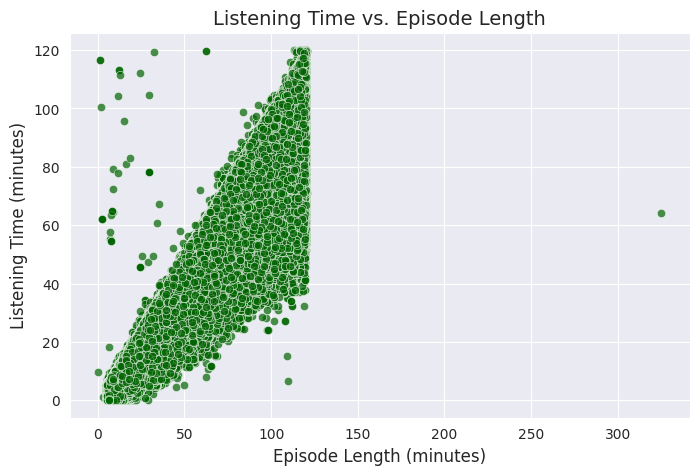

In [16]:
# 2. Listening Time vs. Episode Length
plt.figure(figsize=(8, 5))
sns.scatterplot(x=train['Episode_Length_minutes'], y=train['Listening_Time_minutes'], alpha=0.7, color='darkgreen')
plt.title("Listening Time vs. Episode Length")
plt.xlabel("Episode Length (minutes)")
plt.ylabel("Listening Time (minutes)")
plt.show()

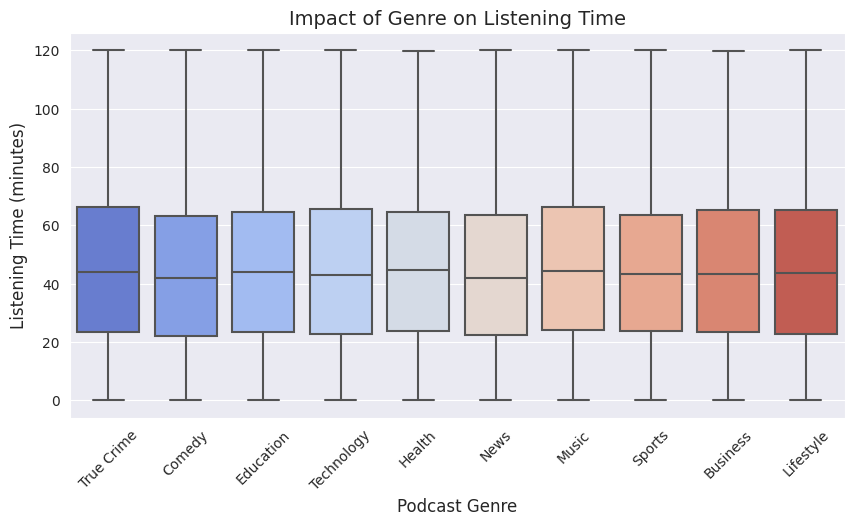

In [17]:
# 3. Impact of Genre on Listening Time
plt.figure(figsize=(10, 5))
sns.boxplot(x="Genre", y="Listening_Time_minutes", data=train, palette="coolwarm")
plt.xticks(rotation=45)
plt.title("Impact of Genre on Listening Time")
plt.xlabel("Podcast Genre")
plt.ylabel("Listening Time (minutes)")
plt.show()

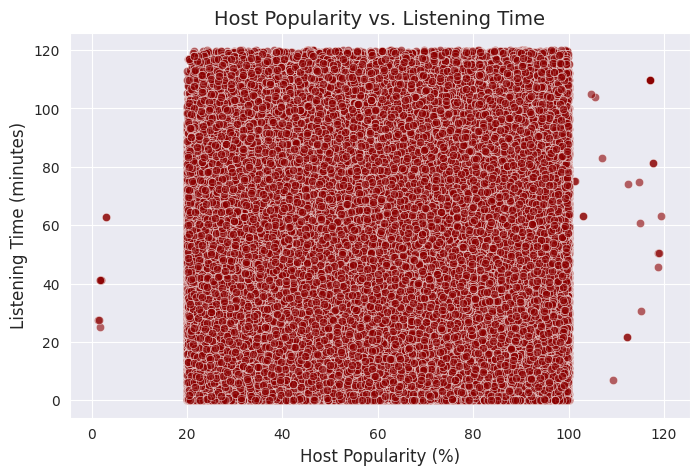

In [18]:
# 4. Host Popularity vs. Listening Time
plt.figure(figsize=(8, 5))
sns.scatterplot(x=train['Host_Popularity_percentage'], y=train['Listening_Time_minutes'], alpha=0.6, color='darkred')
plt.title("Host Popularity vs. Listening Time")
plt.xlabel("Host Popularity (%)")
plt.ylabel("Listening Time (minutes)")
plt.show()

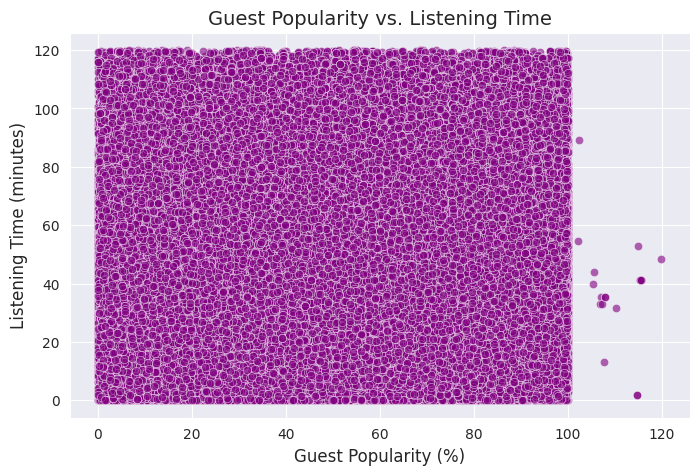

In [19]:
# 5. Guest Popularity vs. Listening Time
plt.figure(figsize=(8, 5))
sns.scatterplot(x=train['Guest_Popularity_percentage'], y=train['Listening_Time_minutes'], alpha=0.6, color='purple')
plt.title("Guest Popularity vs. Listening Time")
plt.xlabel("Guest Popularity (%)")
plt.ylabel("Listening Time (minutes)")
plt.show()

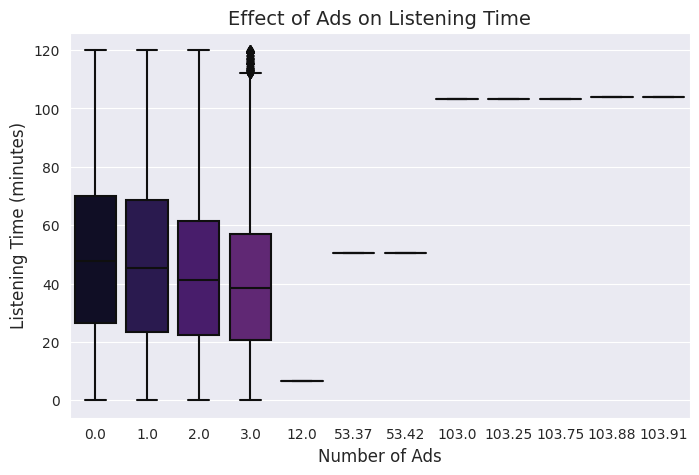

In [20]:
# 6. Effect of Number of Ads on Listening Time
plt.figure(figsize=(8, 5))
sns.boxplot(x="Number_of_Ads", y="Listening_Time_minutes", data=train, palette="magma")
plt.title("Effect of Ads on Listening Time")
plt.xlabel("Number of Ads")
plt.ylabel("Listening Time (minutes)")
plt.show()

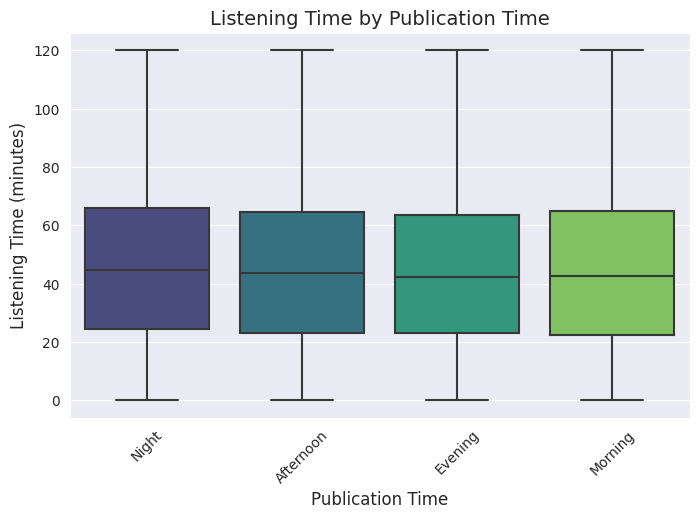

In [21]:
# 7. Publication Time Patterns
plt.figure(figsize=(8, 5))
sns.boxplot(x=train["Publication_Time"], y=train["Listening_Time_minutes"], palette="viridis")
plt.xticks(rotation=45)
plt.title("Listening Time by Publication Time")
plt.xlabel("Publication Time")
plt.ylabel("Listening Time (minutes)")
plt.show()

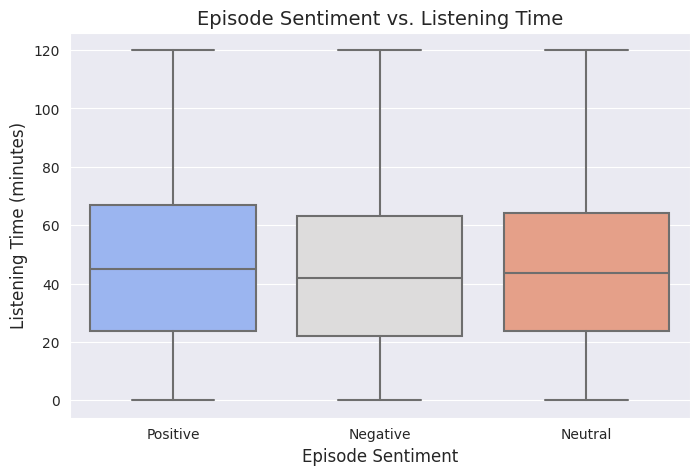

In [22]:
# 8. Sentiment Analysis vs. Listening Time
plt.figure(figsize=(8, 5))
sns.boxplot(x="Episode_Sentiment", y="Listening_Time_minutes", data=train, palette="coolwarm")
plt.title("Episode Sentiment vs. Listening Time")
plt.xlabel("Episode Sentiment")
plt.ylabel("Listening Time (minutes)")
plt.show()

In [23]:
test.head()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment
0,750000,Educational Nuggets,Episode 73,78.96,Education,38.11,Saturday,Evening,53.33,1.0,Neutral
1,750001,Sound Waves,Episode 23,27.87,Music,71.29,Sunday,Morning,NaN,0.0,Neutral
2,750002,Joke Junction,Episode 11,69.10,Comedy,67.89,Friday,Evening,97.51,0.0,Positive
3,750003,Comedy Corner,Episode 73,115.39,Comedy,23.40,Sunday,Morning,51.75,2.0,Positive
4,750004,Life Lessons,Episode 50,72.32,Lifestyle,58.10,Wednesday,Morning,11.30,2.0,Neutral


In [24]:
test.tail()

,id,Podcast_Name,Episode_Title,Episode_Length_minutes,Genre,Host_Popularity_percentage,Publication_Day,Publication_Time,Guest_Popularity_percentage,Number_of_Ads,Episode_Sentiment
249995,999995,Mind & Body,Episode 100,21.05,Health,65.77,Saturday,Evening,96.40,3.0,Negative
249996,999996,Joke Junction,Episode 85,85.50,Comedy,41.47,Saturday,Night,30.52,2.0,Negative
249997,999997,Joke Junction,Episode 63,12.11,Comedy,25.92,Thursday,Evening,73.69,1.0,Neutral
249998,999998,Market Masters,Episode 46,113.46,Business,43.47,Friday,Night,93.59,3.0,Positive
249999,999999,Brain Boost,Episode 46,78.05,Education,41.72,Friday,Morning,50.77,0.0,Negative


In [25]:
test.describe()

,id,Episode_Length_minutes,Host_Popularity_percentage,Guest_Popularity_percentage,Number_of_Ads
count,250000.000000,2.212640e+05,250000.000000,201168.000000,250000.000000
mean,874999.500000,4.192987e+02,59.716491,52.192796,1.355852
std,72168.927986,1.668545e+05,22.880028,28.445034,4.274399
min,750000.000000,2.470000e+00,2.490000,0.000000,0.000000
25%,812499.750000,3.578000e+01,39.250000,28.320000,0.000000
50%,874999.500000,6.397000e+01,59.900000,53.360000,1.000000
75%,937499.250000,9.415000e+01,79.390000,76.560000,2.000000
max,999999.000000,7.848626e+07,117.760000,116.820000,2063.000000


In [26]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 11 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           250000 non-null  int64  
 1   Podcast_Name                 250000 non-null  object 
 2   Episode_Title                250000 non-null  object 
 3   Episode_Length_minutes       221264 non-null  float64
 4   Genre                        250000 non-null  object 
 5   Host_Popularity_percentage   250000 non-null  float64
 6   Publication_Day              250000 non-null  object 
 7   Publication_Time             250000 non-null  object 
 8   Guest_Popularity_percentage  201168 non-null  float64
 9   Number_of_Ads                250000 non-null  float64
 10  Episode_Sentiment            250000 non-null  object 
dtypes: float64(4), int64(1), object(6)
memory usage: 21.0+ MB


In [27]:
test.isnull().sum()

id                                 0
Podcast_Name                       0
Episode_Title                      0
Episode_Length_minutes         28736
Genre                              0
Host_Popularity_percentage         0
Publication_Day                    0
Publication_Time                   0
Guest_Popularity_percentage    48832
Number_of_Ads                      0
Episode_Sentiment                  0
dtype: int64

In [28]:
test.duplicated().sum()

0

In [29]:
test.dtypes

id                               int64
Podcast_Name                    object
Episode_Title                   object
Episode_Length_minutes         float64
Genre                           object
Host_Popularity_percentage     float64
Publication_Day                 object
Publication_Time                object
Guest_Popularity_percentage    float64
Number_of_Ads                  float64
Episode_Sentiment               object
dtype: object

In [30]:
test.shape

(250000, 11)

In [31]:
test.columns

Index(['id', 'Podcast_Name', 'Episode_Title', 'Episode_Length_minutes',
       'Genre', 'Host_Popularity_percentage', 'Publication_Day',
       'Publication_Time', 'Guest_Popularity_percentage', 'Number_of_Ads',
       'Episode_Sentiment'],
      dtype='object')

## Data Visulizations - test dataset

In [32]:
# Set seaborn style
sns.set_style("darkgrid")
plt.rcParams.update({'axes.titlesize': 14, 'axes.labelsize': 12, 'xtick.labelsize': 10, 'ytick.labelsize': 10})

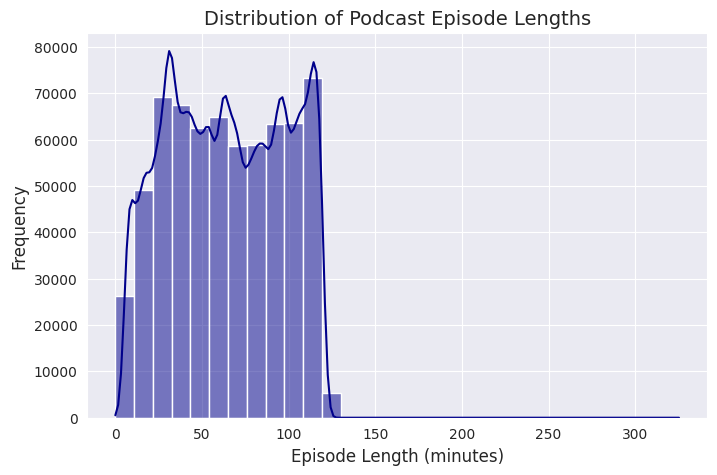

In [33]:
# 1. Distribution of Episode Lengths
plt.figure(figsize=(8, 5))
sns.histplot(train['Episode_Length_minutes'], bins=30, kde=True, color='darkblue')
plt.title("Distribution of Podcast Episode Lengths")
plt.xlabel("Episode Length (minutes)")
plt.ylabel("Frequency")
plt.show()

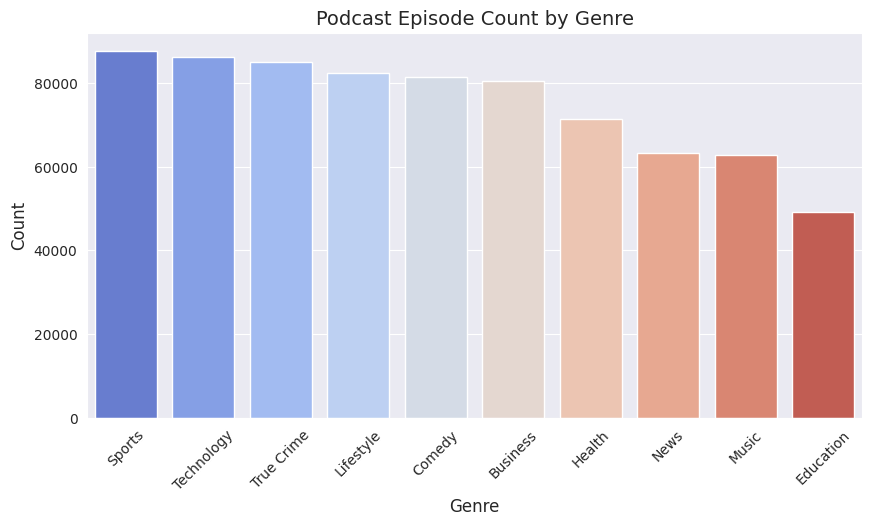

In [34]:
# 2. Genre-wise Episode Count
plt.figure(figsize=(10, 5))
sns.countplot(x="Genre", data=train, palette="coolwarm", order=train["Genre"].value_counts().index)
plt.xticks(rotation=45)
plt.title("Podcast Episode Count by Genre")
plt.xlabel("Genre")
plt.ylabel("Count")
plt.show()

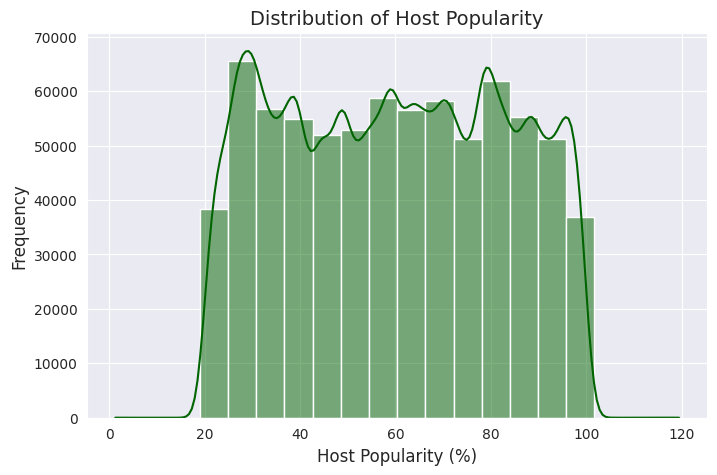

In [35]:
# 3. Host Popularity Distribution
plt.figure(figsize=(8, 5))
sns.histplot(train["Host_Popularity_percentage"], bins=20, kde=True, color='darkgreen')
plt.title("Distribution of Host Popularity")
plt.xlabel("Host Popularity (%)")
plt.ylabel("Frequency")
plt.show()

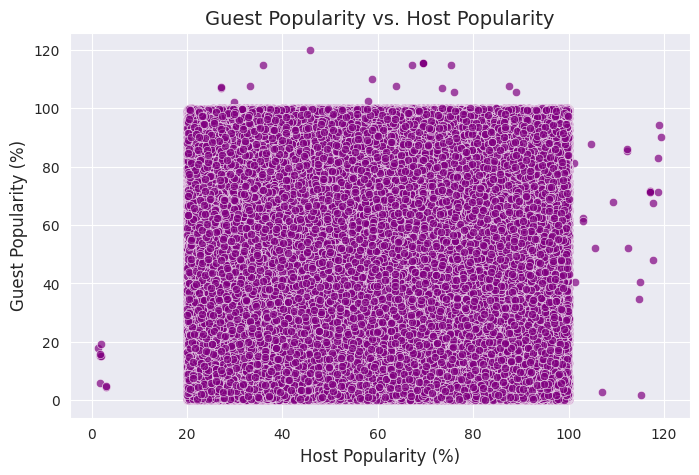

In [36]:
# 4. Guest Popularity vs. Host Popularity
plt.figure(figsize=(8, 5))
sns.scatterplot(x=train["Host_Popularity_percentage"], y=train["Guest_Popularity_percentage"], alpha=0.7, color='purple')
plt.title("Guest Popularity vs. Host Popularity")
plt.xlabel("Host Popularity (%)")
plt.ylabel("Guest Popularity (%)")
plt.show()

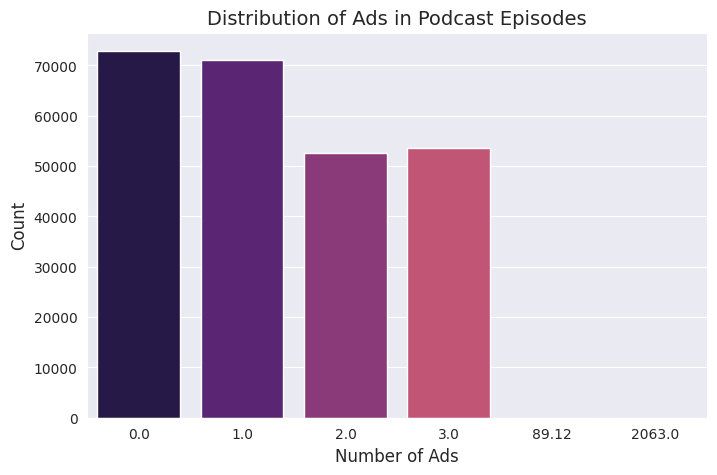

In [37]:
# 5. Ads Count in Episodes
plt.figure(figsize=(8, 5))
sns.countplot(x="Number_of_Ads", data=test, palette="magma")
plt.title("Distribution of Ads in Podcast Episodes")
plt.xlabel("Number of Ads")
plt.ylabel("Count")
plt.show()

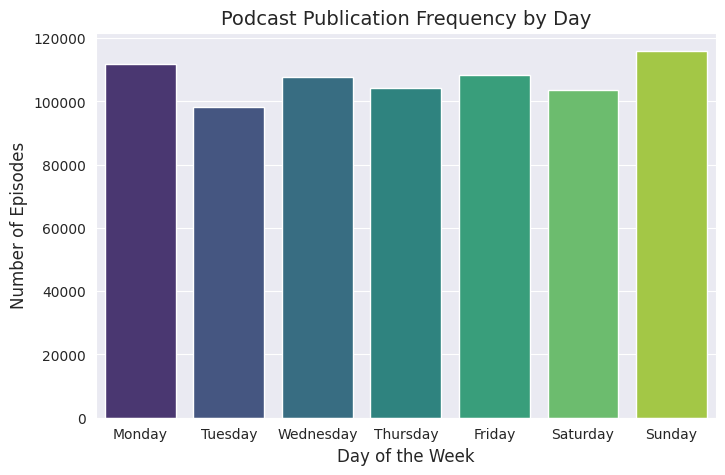

In [38]:
# 6. Publication Day Trends
plt.figure(figsize=(8, 5))
sns.countplot(x="Publication_Day", data=train, palette="viridis", order=["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"])
plt.title("Podcast Publication Frequency by Day")
plt.xlabel("Day of the Week")
plt.ylabel("Number of Episodes")
plt.show()

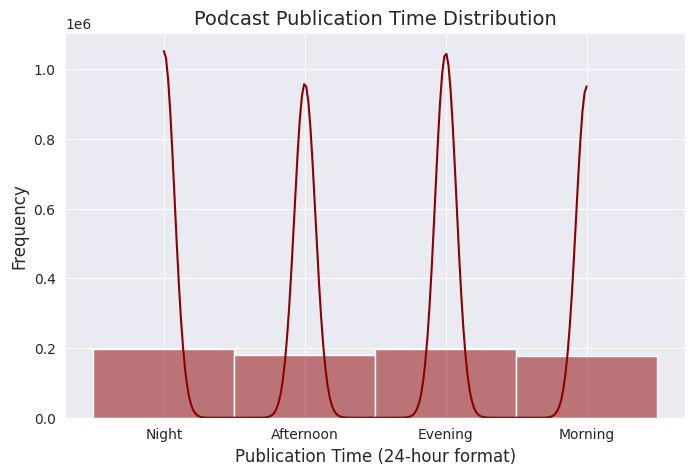

In [39]:
# 7. Publication Time Trends
plt.figure(figsize=(8, 5))
sns.histplot(train["Publication_Time"], bins=24, kde=True, color='darkred')
plt.title("Podcast Publication Time Distribution")
plt.xlabel("Publication Time (24-hour format)")
plt.ylabel("Frequency")
plt.show()

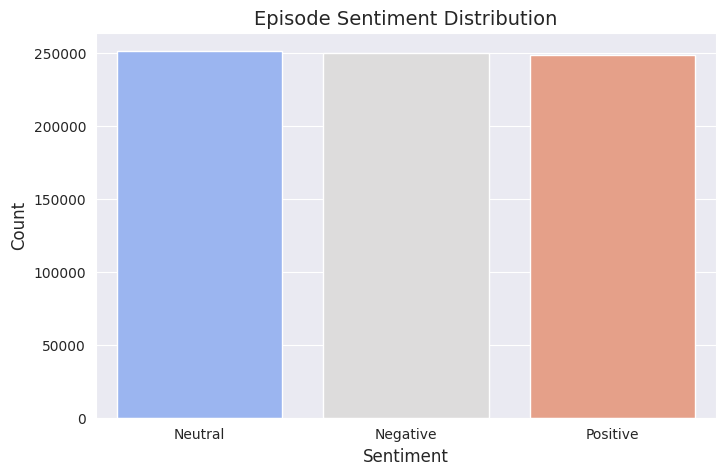

In [40]:
# 8. Episode Sentiment Distribution
plt.figure(figsize=(8, 5))
sns.countplot(x="Episode_Sentiment", data=train, palette="coolwarm", order=train["Episode_Sentiment"].value_counts().index)
plt.title("Episode Sentiment Distribution")
plt.xlabel("Sentiment")
plt.ylabel("Count")
plt.show()

In [41]:
num_cols = train.select_dtypes(include=['float64', 'int64']).columns
cat_cols = train.select_dtypes(include=['object']).columns

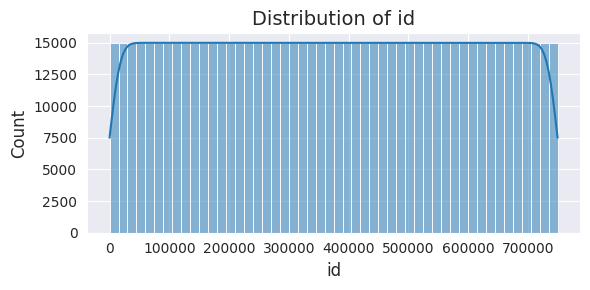

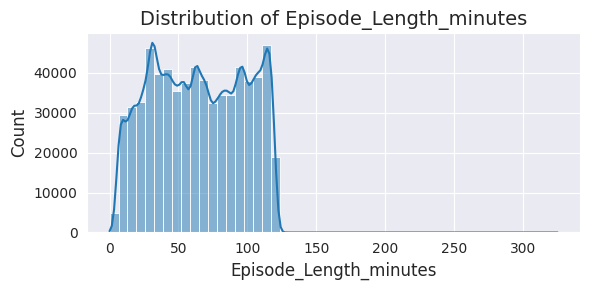

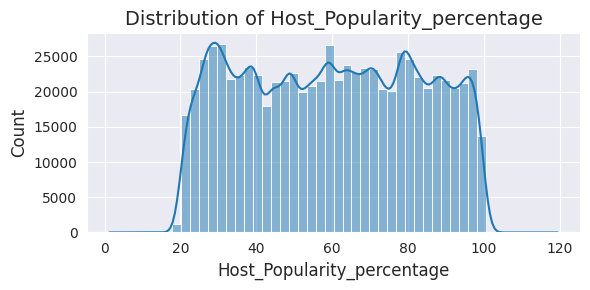

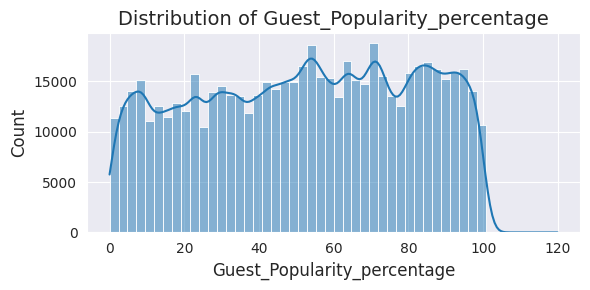

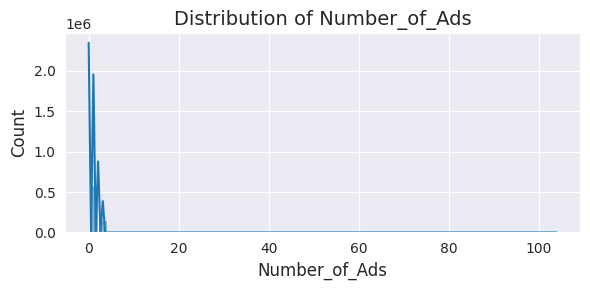

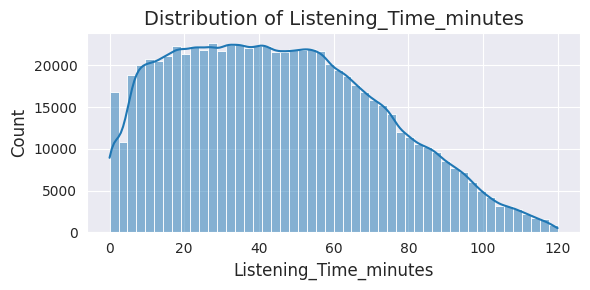

In [42]:
for col in num_cols:
    plt.figure(figsize=(6, 3))
    sns.histplot(train[col], kde=True, bins=50)
    plt.title(f'Distribution of {col}')
    plt.tight_layout()
    plt.show()

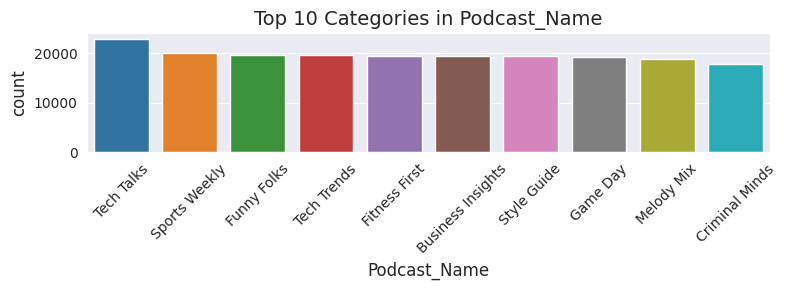

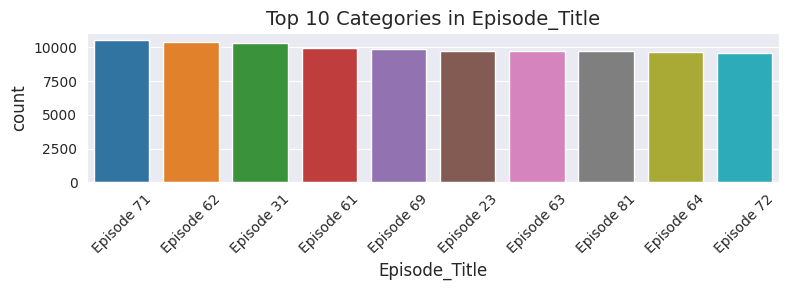

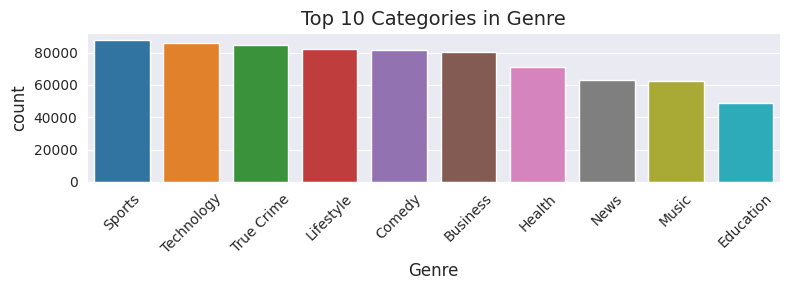

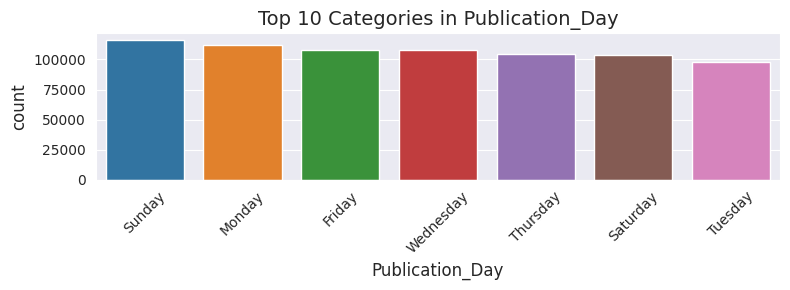

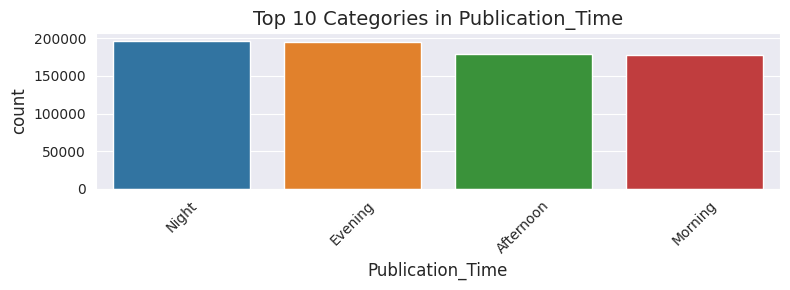

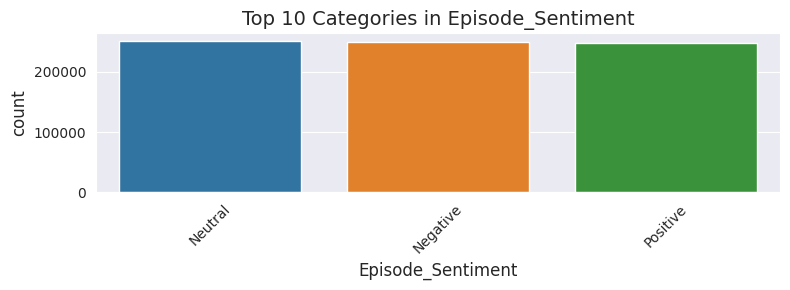

In [43]:
for col in cat_cols:
    plt.figure(figsize=(8, 3))
    top_vals = train[col].value_counts().nlargest(10).index
    sns.countplot(data=train[train[col].isin(top_vals)], x=col, order=top_vals)
    plt.xticks(rotation=45)
    plt.title(f'Top 10 Categories in {col}')
    plt.tight_layout()
    plt.show()

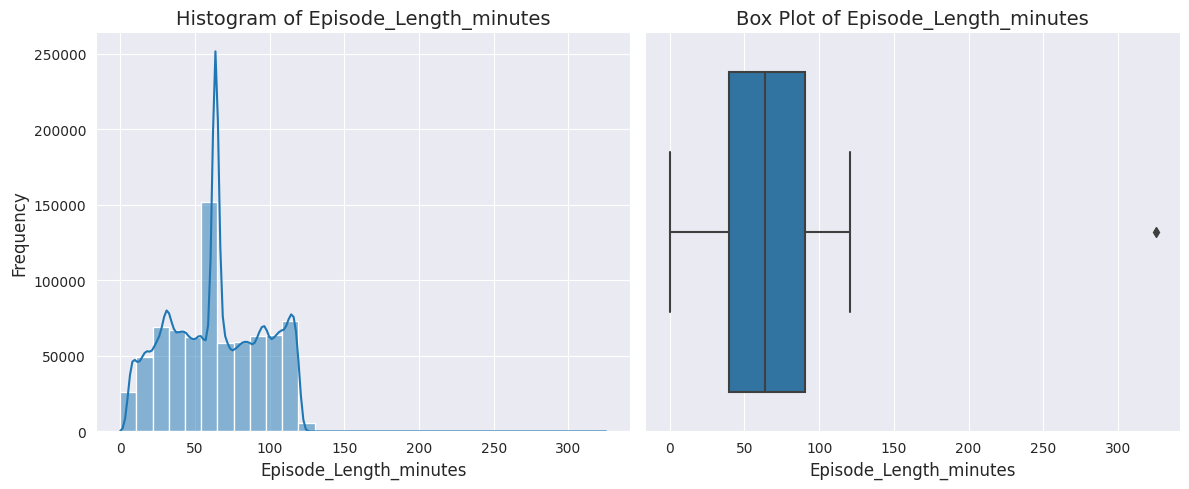


Statistics for Episode_Length_minutes:
Skewness: 0.01
Missing Values: 0


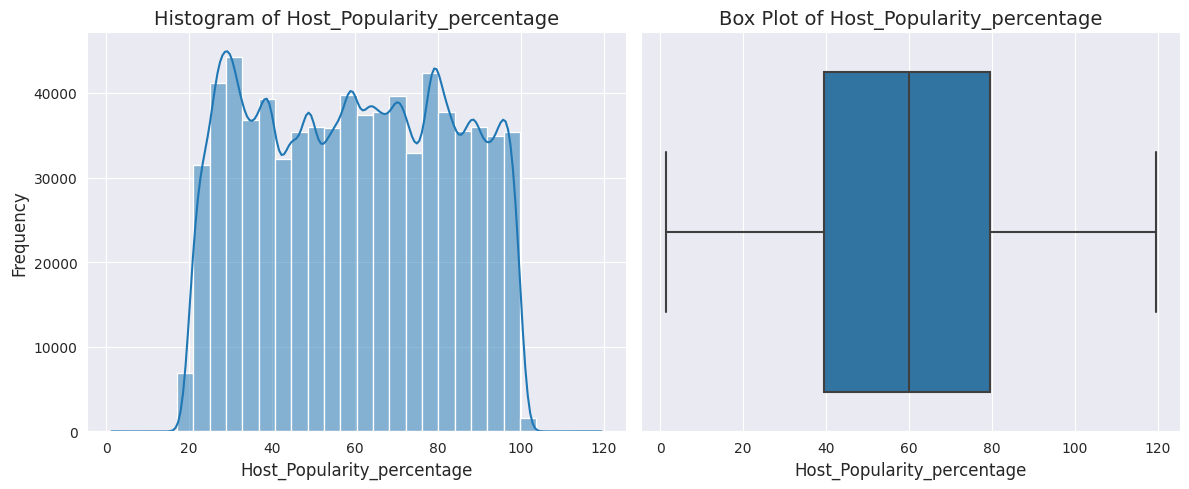


Statistics for Host_Popularity_percentage:
Skewness: 0.00
Missing Values: 0


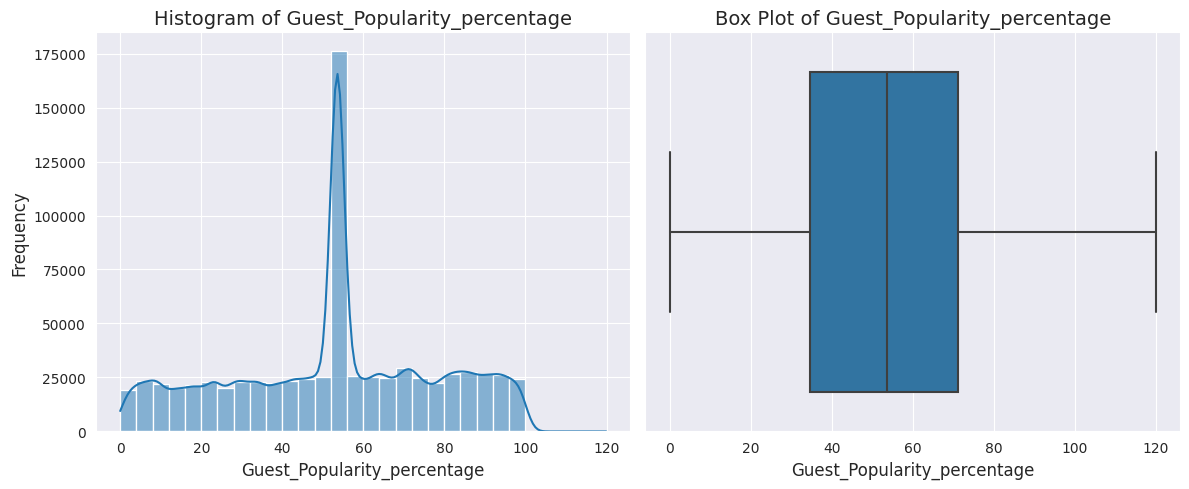


Statistics for Guest_Popularity_percentage:
Skewness: -0.15
Missing Values: 0


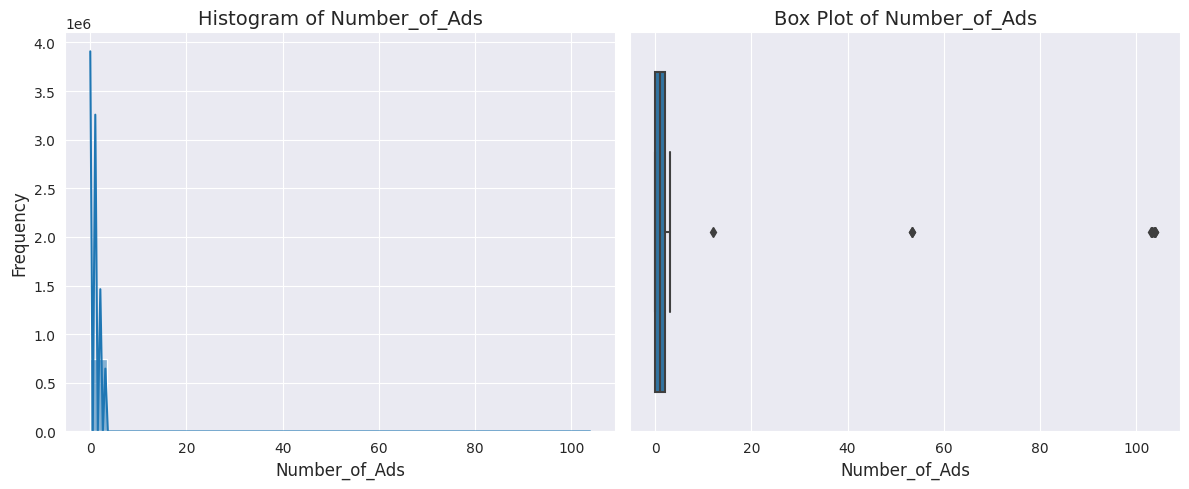


Statistics for Number_of_Ads:
Skewness: 6.03
Missing Values: 0


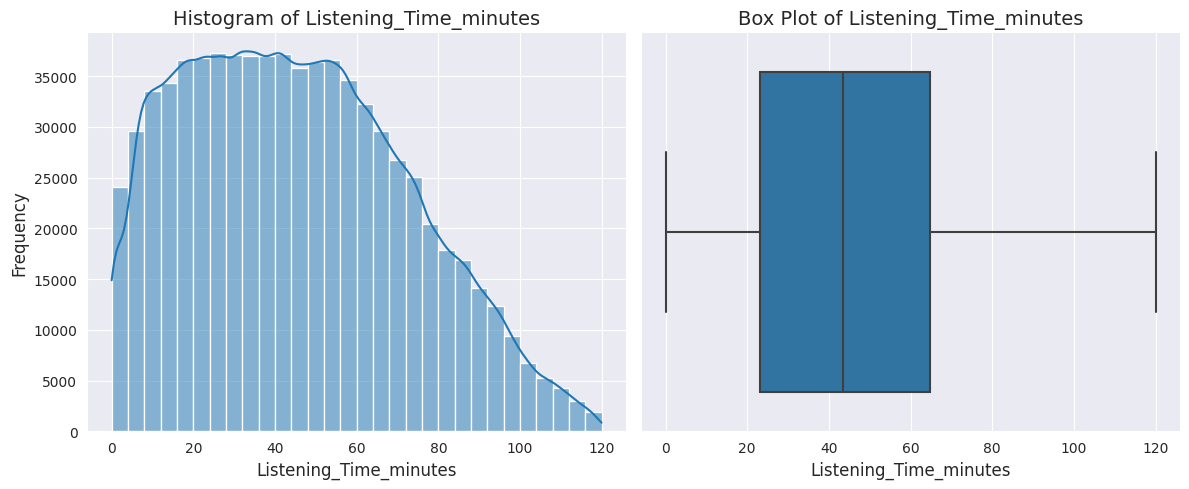


Statistics for Listening_Time_minutes:
Skewness: 0.35
Missing Values: 0


In [44]:

if not isinstance(train, pd.DataFrame):
    raise TypeError("train must be a pandas DataFrame")

numerical_features = [
    "Episode_Length_minutes",
    "Host_Popularity_percentage",
    "Guest_Popularity_percentage",
    "Number_of_Ads",
    "Listening_Time_minutes",
]

# Validate column names
missing_cols = [col for col in numerical_features if col not in train.columns]
if missing_cols:
    raise ValueError(f"Missing columns in train: {missing_cols}")

# Plot histograms and box plots for each numerical feature
for feature in numerical_features:
    plt.figure(figsize=(12, 5))

    # Handle missing values
    train[feature] = pd.to_numeric(train[feature], errors='coerce')
    train[feature].fillna(train[feature].median(), inplace=True)

    # Histogram with KDE
    plt.subplot(1, 2, 1)
    sns.histplot(train[feature], kde=True, bins=30)
    plt.title(f"Histogram of {feature}")
    plt.xlabel(feature)
    plt.ylabel("Frequency")

    # Box plot
    plt.subplot(1, 2, 2)
    sns.boxplot(x=train[feature])
    plt.title(f"Box Plot of {feature}")

    plt.tight_layout()
    plt.show()

    # Print statistics
    print(f"\nStatistics for {feature}:")
    print(f"Skewness: {train[feature].skew():.2f}")
    print(f"Missing Values: {train[feature].isnull().sum()}")

## Handling Missing values

In [45]:
cols_to_fill = ['Episode_Length_minutes', 'Guest_Popularity_percentage', 'Number_of_Ads']
train[cols_to_fill] = train[cols_to_fill].fillna(train[cols_to_fill].mean())
test[cols_to_fill] = test[cols_to_fill].fillna(test[cols_to_fill].mean())

In [46]:
train.isnull().sum()

id                             0
Podcast_Name                   0
Episode_Title                  0
Episode_Length_minutes         0
Genre                          0
Host_Popularity_percentage     0
Publication_Day                0
Publication_Time               0
Guest_Popularity_percentage    0
Number_of_Ads                  0
Episode_Sentiment              0
Listening_Time_minutes         0
dtype: int64

In [47]:
test.isnull().sum()

id                             0
Podcast_Name                   0
Episode_Title                  0
Episode_Length_minutes         0
Genre                          0
Host_Popularity_percentage     0
Publication_Day                0
Publication_Time               0
Guest_Popularity_percentage    0
Number_of_Ads                  0
Episode_Sentiment              0
dtype: int64

In [48]:
# columns with NaN values 
cols_fillna = ["Episode_Length_minutes", "Guest_Popularity_percentage", "Number_of_Ads"]

# replace 'NaN' with '0' in these columns
for col in cols_fillna:
    train[col].fillna('0',inplace=True)
    test[col].fillna('0',inplace=True)

In [49]:

train_na = (train.isnull().sum() / len(train)) * 100
train_na = train_na.drop(train_na[train_na == 0].index).sort_values(ascending=False)
missing_data = pd.DataFrame({'Missing Ratio' :train_na})
missing_data.head()


,Missing Ratio


## Label Encoding

## Predictive modeling

In [50]:
import category_encoders as ce
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from sklearn.model_selection import KFold, cross_val_score
from sklearn.metrics import mean_squared_error
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder

In [51]:
X = train.drop(columns=['Listening_Time_minutes'])
y = train[['Listening_Time_minutes']]

In [52]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=42)

In [53]:
# Split data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [54]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42),
    "Support Vector Machine": SVC(kernel='linear')
}


In [55]:
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object']).columns.tolist()


# pipelines
preprocessor = ColumnTransformer(
    transformers=[
        ('num', SimpleImputer(strategy='median'), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse=False), categorical_features)
    ]
)

In [56]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, f_regression

kbest = SelectKBest(score_func=f_regression, k=5)

In [57]:
rf = RandomForestRegressor(max_features=0.75, max_samples=0.75, n_estimators=400, n_jobs=-1)

In [58]:
pipe = Pipeline(steps=[
    ('preprocessor', preprocessor),
    ('kbest', kbest),
    ('RF_regressor', rf)
])

In [59]:
pipe.fit(X_train,y_train.values.ravel())

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(transformers=[('num',
                                                  SimpleImputer(strategy='median'),
                                                  ['id',
                                                   'Episode_Length_minutes',
                                                   'Host_Popularity_percentage',
                                                   'Guest_Popularity_percentage',
                                                   'Number_of_Ads']),
                                                 ('cat',
                                                  OneHotEncoder(handle_unknown='ignore',
                                                                sparse=False),
                                                  ['Podcast_Name',
                                                   'Episode_Title', 'Genre',
                                                   'Publication_Day',
                                                   'Publication_Time',
                                                   'Episode_Sentiment'])])),
                ('kbest',
                 SelectKBest(k=5,
                             score_func=<function f_regression at 0x7bdb1d21d630>)),
                ('RF_regressor',
                 RandomForestRegressor(max_features=0.75, max_samples=0.75,
                                       n_estimators=400, n_jobs=-1))])

In [60]:
y_pred = pipe.predict(X_test)

In [61]:
from sklearn.metrics import accuracy_score, r2_score
r2_score(y_test,y_pred)

0.7463326070610158

## Thank you..pls uopvote!!!!